# MLP
## Simple MLP with meta data for comparison

## 01 Load Data

In [1]:
pip install torch

  Using cached torch-2.7.1-cp311-cp311-manylinux_2_28_x86_64.whl.metadata (29 kB)
  Using cached filelock-3.18.0-py3-none-any.whl.metadata (2.9 kB)
  Using cached typing_extensions-4.14.1-py3-none-any.whl.metadata (3.0 kB)
  Using cached sympy-1.14.0-py3-none-any.whl.metadata (12 kB)
  Using cached nvidia_cuda_nvrtc_cu12-12.6.77-py3-none-manylinux2014_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.6.77-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.6.80-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-9.5.1.17-py3-none-manylinux_2_28_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.6.4.1-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.3.0.4-py3-none-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.7.77-py3

In [28]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from tqdm import tqdm
import time

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torch.optim import Adam
import torch.nn.functional as F

from sklearn.preprocessing import StandardScaler
from sklearn.metrics import confusion_matrix, classification_report
from sklearn.model_selection import train_test_split, ParameterGrid

In [3]:
import matplotlib as mpl

# Enable LaTeX-style font
mpl.rcParams['text.usetex'] = True
mpl.rcParams['font.family'] = 'serif'

In [4]:
train_data = pd.read_csv('../02_data/train_test/train_data.csv')
test_data = pd.read_csv('../02_data/train_test/test_data.csv')

In [5]:
print("train_data info")
print(train_data.info())
print("-------------------------------------------------")

print("test_data info")
print(test_data.info())
print("-------------------------------------------------")

train_data info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4884 entries, 0 to 4883
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   domain             4884 non-null   object 
 1   url_index          4884 non-null   object 
 2   article            4884 non-null   object 
 3   article_embedding  4884 non-null   object 
 4   virality           4884 non-null   float64
 5   avalanches         4884 non-null   float64
 6   messages           4884 non-null   float64
 7   chats              4884 non-null   float64
 8   pc1                4884 non-null   float64
 9   domain_id          4884 non-null   int64  
dtypes: float64(5), int64(1), object(4)
memory usage: 381.7+ KB
None
-------------------------------------------------
test_data info
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1222 entries, 0 to 1221
Data columns (total 10 columns):
 #   Column             Non-Null Count  Dtype  
---  ------ 

## 02 Preprocessing

In [6]:
train_data['label'] = pd.cut(train_data['pc1'], bins=[-float('inf'), 0.33, 0.66, float('inf')], labels=[0, 1, 2]).astype(int)
test_data['label'] = pd.cut(test_data['pc1'], bins=[-float('inf'), 0.33, 0.66, float('inf')], labels=[0, 1, 2]).astype(int)

In [7]:
train_counts = train_data['label'].value_counts().sort_index()
test_counts = test_data['label'].value_counts().sort_index()

# Get percentages
train_percentages = train_counts / train_counts.sum() * 100
test_percentages = test_counts / test_counts.sum() * 100

# Display nicely
distribution = pd.DataFrame({
    'Train Count': train_counts,
    'Train %': train_percentages.round(2),
    'Test Count': test_counts,
    'Test %': test_percentages.round(2)
})

print(distribution)

       Train Count  Train %  Test Count  Test %
label                                          
0              720    14.74         171   13.99
1             2125    43.51         549   44.93
2             2039    41.75         502   41.08


In [8]:
features = ["virality", "avalanches", "messages", "chats"]
X = train_data[features].values
y = train_data["label"].values
X_test = test_data[features].values
y_test = test_data["label"].values

# train val split
X_train, X_val, y_train, y_val = train_test_split(X, y, test_size=0.2, random_state=42)

# Standardize features
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_val = scaler.transform(X_val)
X_test = scaler.transform(X_test)

In [9]:
# dataset class
def tensor_dataset(X, y):
    return torch.utils.data.TensorDataset(torch.tensor(X, dtype=torch.float32), torch.tensor(y, dtype=torch.long))

In [10]:
train_dataset = tensor_dataset(X_train, y_train)
val_dataset = tensor_dataset(X_val, y_val)
test_dataset = tensor_dataset(X_test, y_test)

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)
test_loader = DataLoader(test_dataset, batch_size=64, shuffle=False)

## 03 Model

In [11]:
from sklearn.utils.class_weight import compute_class_weight

class_weights = compute_class_weight('balanced', classes=[0, 1, 2], y=y)
class_weights = torch.tensor(class_weights, dtype=torch.float)

In [12]:
class MLP(nn.Module):
    def __init__(self, input_size, hidden_size, output_size):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, hidden_size),
            nn.ReLU(),
            nn.Linear(hidden_size, output_size)
        )

    def forward(self, x):
        return self.model(x)

In [13]:
class MLP(nn.Module):
    def __init__(self, input_dim, hidden_dim=64, output_dim=3, dropout=0.5):
        super(MLP, self).__init__()
        self.model = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        x = self.model(x)
        return F.log_softmax(x, dim=1)

In [18]:
import time

def train_model(hidden_size, learning_rate, num_epochs=20, clip_grad_norm=None, dropout=0.5):
    model = MLP(input_size=4, hidden_size=hidden_size, output_size=3, dropout=0.5)
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=learning_rate)
    scheduler = torch.optim.lr_scheduler.StepLR(optimizer, step_size=10, gamma=0.5)

    train_losses = []
    val_losses = []

    start_time = time.time()  # Start measuring time

    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad()
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            loss.backward()
            
            if clip_grad_norm:
                torch.nn.utils.clip_grad_norm_(model.parameters(), clip_grad_norm)
            
            optimizer.step()
            running_loss += loss.item()

        train_loss = running_loss / len(train_loader)
        train_losses.append(train_loss)

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for X_batch, y_batch in val_loader:
                outputs = model(X_batch)
                loss = criterion(outputs, y_batch)
                val_loss += loss.item()
        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        scheduler.step()

    training_time = time.time() - start_time  # End measuring time

    return model, train_losses, val_losses, training_time


## 04 Hyperparameter TUning

In [24]:
# Check if GPU is available
device = torch.device("cuda") if torch.cuda.is_available() else torch.device("cpu")
print(device)

cuda


In [22]:
input_dim = X_train.shape[1]

# Define param grid
param_grid = {
    "hidden_size": [32, 64, 128],
    "dropout": [0, 0.3, 0.5],
    "learning_rate": [0.01, 0.005, 0.001],
    "weight_decay": [1e-5, 1e-4, 1e-3]
}

param_grid = list(ParameterGrid(param_grid))

In [29]:
best_val_loss = float("inf")
best_model = None
best_params = None

for params in param_grid:
    print(f"Testing params: {params}")
    
    model = MLP(input_dim=input_dim, hidden_dim=params["hidden_size"], output_dim=3, dropout=params["dropout"]).to(device)
    optimizer = Adam(model.parameters(), lr=params["learning_rate"], weight_decay=params["weight_decay"])
    criterion = nn.CrossEntropyLoss()

    train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
    val_loader = DataLoader(val_dataset, batch_size=32)

    train_losses, val_losses = [], []

    for epoch in range(100):  
        model.train()
        running_loss = 0.0
        for xb, yb in train_loader:
            xb, yb = xb.to(device), yb.to(device)
            optimizer.zero_grad()
            preds = model(xb)
            loss = criterion(preds, yb)
            loss.backward()
            optimizer.step()
            running_loss += loss.item()
        train_losses.append(running_loss / len(train_loader))

        model.eval()
        val_loss = 0.0
        with torch.no_grad():
            for xb, yb in val_loader:
                xb, yb = xb.to(device), yb.to(device)
                preds = model(xb)
                loss = criterion(preds, yb)
                val_loss += loss.item()
        val_losses.append(val_loss / len(val_loader))

    # Save best
    if val_losses[-1] < best_val_loss:
        best_val_loss = val_losses[-1]
        best_model = model
        best_params = params
        best_train_losses = train_losses
        best_val_losses = val_losses

# Report
print("Best Params:", best_params)
print("Validation Loss:", best_val_loss)


Testing params: {'dropout': 0, 'hidden_size': 32, 'learning_rate': 0.01, 'weight_decay': 1e-05}
Testing params: {'dropout': 0, 'hidden_size': 32, 'learning_rate': 0.01, 'weight_decay': 0.0001}
Testing params: {'dropout': 0, 'hidden_size': 32, 'learning_rate': 0.01, 'weight_decay': 0.001}
Testing params: {'dropout': 0, 'hidden_size': 32, 'learning_rate': 0.005, 'weight_decay': 1e-05}
Testing params: {'dropout': 0, 'hidden_size': 32, 'learning_rate': 0.005, 'weight_decay': 0.0001}
Testing params: {'dropout': 0, 'hidden_size': 32, 'learning_rate': 0.005, 'weight_decay': 0.001}
Testing params: {'dropout': 0, 'hidden_size': 32, 'learning_rate': 0.001, 'weight_decay': 1e-05}
Testing params: {'dropout': 0, 'hidden_size': 32, 'learning_rate': 0.001, 'weight_decay': 0.0001}
Testing params: {'dropout': 0, 'hidden_size': 32, 'learning_rate': 0.001, 'weight_decay': 0.001}
Testing params: {'dropout': 0, 'hidden_size': 64, 'learning_rate': 0.01, 'weight_decay': 1e-05}
Testing params: {'dropout': 0, 

In [15]:
model, train_losses, val_losses, training_time = train_model(hidden_size=128, learning_rate=0.01, num_epochs=20, clip_grad_norm=1.0)
torch.save(model.state_dict(), "../03_plots/content_agnostic/mlp_model.pth")

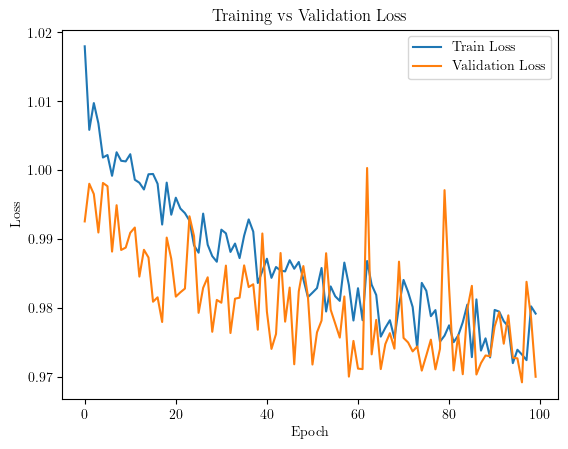

In [30]:
# Plot training and validation loss
#plt.figure(figsize=(10, 6))
plt.plot(best_train_losses, label='Train Loss')
plt.plot(best_val_losses, label='Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('Training vs Validation Loss')
plt.savefig('../03_plots/train_val_MLP_content_agnostic.png')
plt.legend()
plt.show()

## 05 Evaluation

In [40]:
from sklearn.metrics import classification_report

model.eval()
y_pred = []
y_true = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        outputs = model(X_batch)
        preds = torch.argmax(outputs, dim=1).cpu().numpy()
        y_pred.extend(preds)
        y_true.extend(y_batch.numpy())

print(classification_report(y_true, y_pred))


              precision    recall  f1-score   support

           0       0.00      0.00      0.00       171
           1       0.47      0.53      0.50       549
           2       0.47      0.56      0.51       502

    accuracy                           0.47      1222
   macro avg       0.31      0.36      0.34      1222
weighted avg       0.40      0.47      0.43      1222



## 06 Testing

In [15]:
input_dim = 4 
hidden_size = 128
output_dim = 3

model = MLP(input_dim, hidden_size, output_dim)
model.load_state_dict(torch.load("../03_plots/content_agnostic/mlp_model.pth"))
model.eval()

MLP(
  (model): Sequential(
    (0): Linear(in_features=4, out_features=128, bias=True)
    (1): ReLU()
    (2): Linear(in_features=128, out_features=128, bias=True)
    (3): ReLU()
    (4): Linear(in_features=128, out_features=3, bias=True)
  )
)

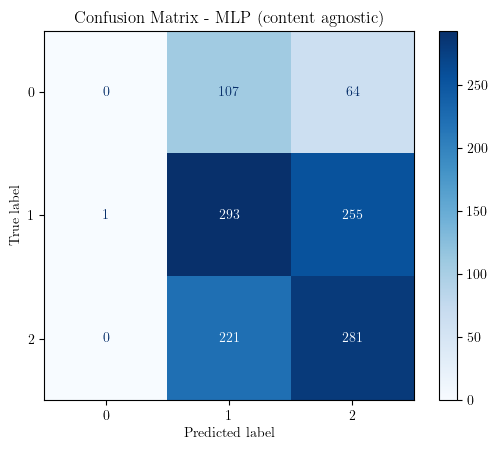

Classification Report:
               precision    recall  f1-score   support

           0       0.00      0.00      0.00       171
           1       0.47      0.53      0.50       549
           2       0.47      0.56      0.51       502

    accuracy                           0.47      1222
   macro avg       0.31      0.36      0.34      1222
weighted avg       0.40      0.47      0.43      1222



In [46]:
# confusion matrix and classification report
conf_matrix = confusion_matrix(y_true, y_pred)
disp = ConfusionMatrixDisplay(conf_matrix) #, display_labels=["Class 0", "Class 1", "Class 2"]
disp.plot(cmap=plt.cm.Blues)
plt.title(f"Confusion Matrix - MLP (content agnostic)")
plt.savefig('../03_plots/con_matrix_MLP_content_agnostic.png')
plt.show()

class_report = classification_report(y_true, y_pred) #, labels=[0,1,2], zero_division=0, output_dict=True
print("Classification Report:\n", class_report)

In [43]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report, confusion_matrix

accuracy = accuracy_score(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

# Print with 4 digits
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")

Accuracy : 0.4697
Precision: 0.4044
Recall   : 0.4697
F1-Score : 0.4345
